<a href="https://colab.research.google.com/github/IshaCodex/OIBSIP/blob/main/DataAnalytics-L2-WineQuality/Task2_WineQuality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load the dataset
df = pd.read_csv('/content/winequality-red.csv')

# Inspect structure
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None


# Exploratory Data Analysis (EDA)

Let's inspect the distribution of the target variable (quality) to see how the wine scores are spread out.

/tmp/ipykernel_541/849851377.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='quality', data=df, palette='muted')


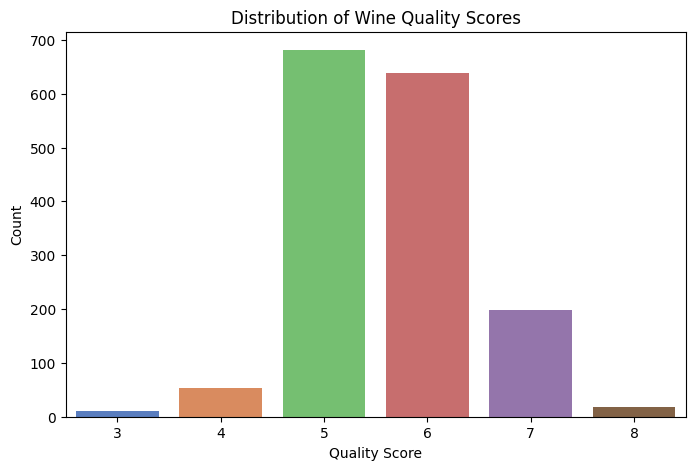

In [2]:
plt.figure(figsize=(8, 5))
sns.countplot(x='quality', data=df, palette='muted')
plt.title('Distribution of Wine Quality Scores')
plt.xlabel('Quality Score')
plt.ylabel('Count')
plt.show()

Now, we will generate a correlation heatmap to understand how the physicochemical properties relate to one another and to the overall quality score.

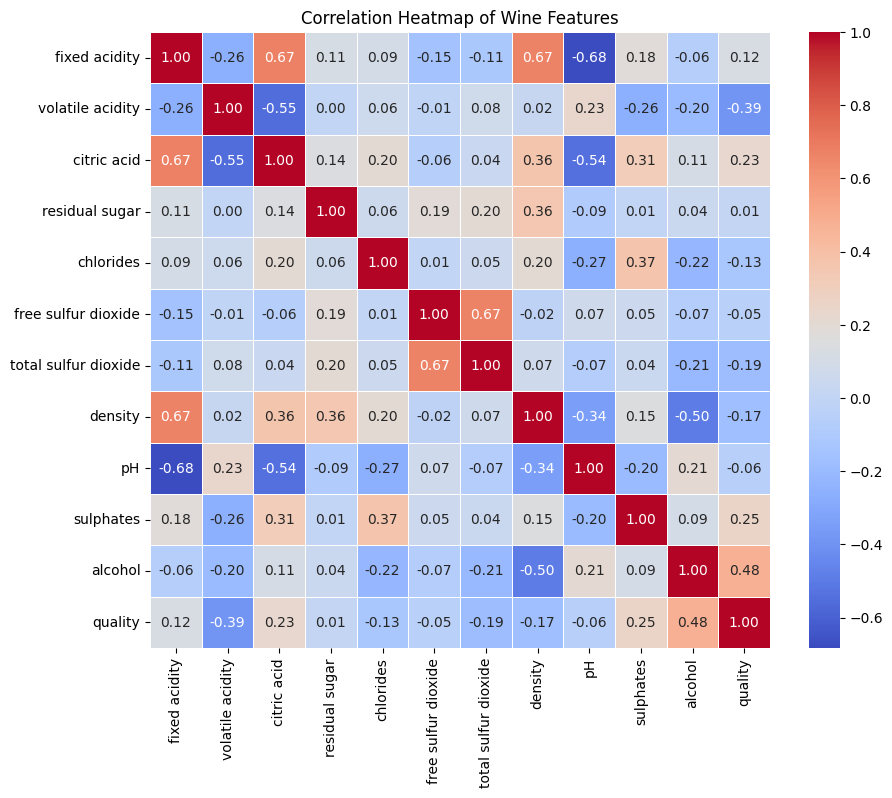

In [3]:
plt.figure(figsize=(10, 8))
correlation = df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Wine Features')
plt.show()

# Class Imbalance & Feature Engineering

As seen in the count plot above, there is a severe class imbalance. Most wines score a 5 or 6, while very few score a 3, 4, 7, or 8. If we train a model on these raw scores, it will struggle to predict the minority classes.
Thus, We will engineer a new binary target variable. Wines with a score of 6 or higher will be classified as "Good" (1), and wines scoring 5 or lower will be classified as "Bad" (0).

In [4]:
# Create a binary classification for wine quality
bins = (2, 5.5, 8) # Scores 3-5 are one bin, 6-8 are another
group_names = ['bad', 'good']
df['quality_binned'] = pd.cut(df['quality'], bins=bins, labels=group_names)

# Map text labels to binary integers (0 and 1)
from sklearn.preprocessing import LabelEncoder
label_quality = LabelEncoder()
df['quality_binned'] = label_quality.fit_transform(df['quality_binned'])

print(df['quality_binned'].value_counts())

quality_binned
1    855
0    744
Name: count, dtype: int64


# Train / Test Split

We will separate our features (X) from our new binned target variable (y) and split the data into training and testing sets. We use stratify=y to ensure the ratio of good-to-bad wines is preserved in both sets.

In [5]:
# Separate features and target
X = df.drop(['quality', 'quality_binned'], axis=1)
y = df['quality_binned']

# Split the data with stratification
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

Training features shape: (1279, 11)
Testing features shape: (320, 11)


# Train Classifiers

We will initialize and train three different classification models: Random Forest, Stochastic Gradient Descent (SGD), and Support Vector Classifier (SVC).

In [6]:
# Initialize models
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
sgd = SGDClassifier(random_state=42)
svc = SVC(random_state=42)

# Train models
rfc.fit(X_train, y_train)
sgd.fit(X_train, y_train)
svc.fit(X_train, y_train)

SVC(random_state=42)

# Evaluate Models

We will generate predictions for each model and evaluate their performance using accuracy scores and classification reports.

In [7]:
# Generate predictions
pred_rfc = rfc.predict(X_test)
pred_sgd = sgd.predict(X_test)
pred_svc = svc.predict(X_test)

print("--- Random Forest Performance ---")
print(classification_report(y_test, pred_rfc))

print("\n--- SGD Performance ---")
print(classification_report(y_test, pred_sgd))

print("\n--- SVC Performance ---")
print(classification_report(y_test, pred_svc))

--- Random Forest Performance ---
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       149
           1       0.84      0.81      0.82       171

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320


--- SGD Performance ---
              precision    recall  f1-score   support

           0       0.63      0.81      0.71       149
           1       0.78      0.58      0.67       171

    accuracy                           0.69       320
   macro avg       0.70      0.70      0.69       320
weighted avg       0.71      0.69      0.68       320


--- SVC Performance ---
              precision    recall  f1-score   support

           0       0.71      0.40      0.52       149
           1       0.62      0.86      0.72       171

    accuracy                           0.65       320
   macro avg       0.67      0.63      0.62 

Next, we will visualize the confusion matrix for the Random Forest model (which typically performs best on this dataset) to see exactly where it made correct predictions versus errors.

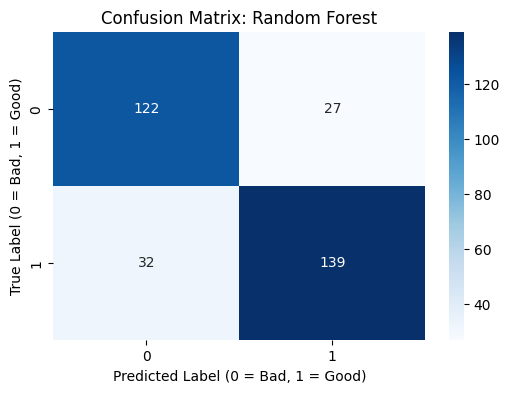

In [8]:
cm = confusion_matrix(y_test, pred_rfc)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Random Forest')
plt.xlabel('Predicted Label (0 = Bad, 1 = Good)')
plt.ylabel('True Label (0 = Bad, 1 = Good)')
plt.show()

# Feature Importance

Tree-based models like Random Forest allow us to extract feature importance, showing us which chemical properties were the strongest predictors of good wine.

/tmp/ipykernel_541/2354574285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')


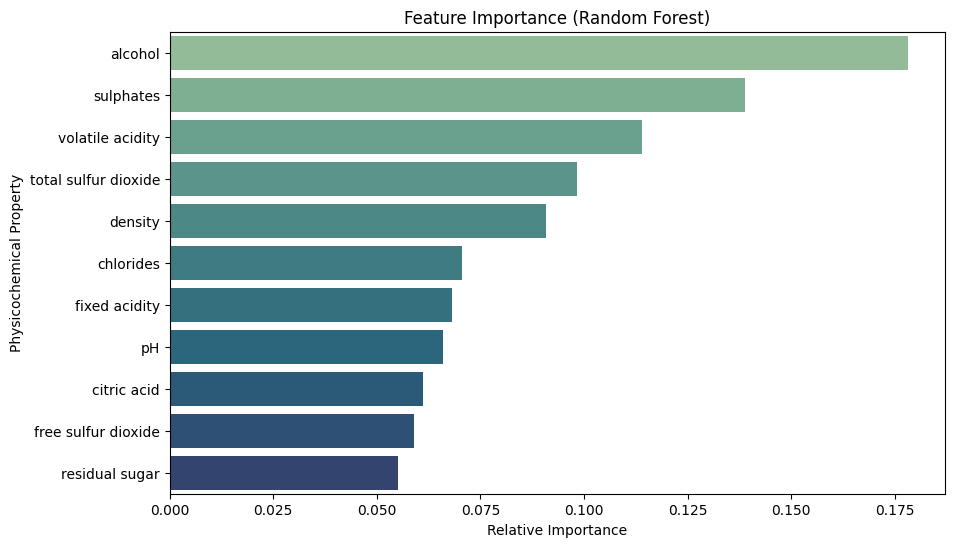

In [9]:
feature_importances = pd.Series(rfc.feature_importances_, index=X.columns)
feature_importances = feature_importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='crest')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Physicochemical Property')
plt.show()

# Model Comparison Table

We will summarize the accuracy of all three models side-by-side for a clean comparison.

In [10]:
# Calculate accuracies
acc_rfc = accuracy_score(y_test, pred_rfc)
acc_sgd = accuracy_score(y_test, pred_sgd)
acc_svc = accuracy_score(y_test, pred_svc)

# Create a comparison dataframe
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'Stochastic Gradient Descent', 'Support Vector Classifier'],
    'Accuracy': [acc_rfc, acc_sgd, acc_svc]
})

display(comparison_df.sort_values(by='Accuracy', ascending=False))

,Model,Accuracy
0,Random Forest,0.815625
1,Stochastic Gradient Descent,0.687500
2,Support Vector Classifier,0.646875


# Conclusion

Based on the comparative analysis, the Random Forest Classifier is the most suitable model for deployment. It achieved the highest overall accuracy and requires less strict feature scaling than distance-based models like SVC or SGD. Additionally, it provides valuable insights into feature importance, revealing that alcohol content and volatile acidity are the most critical chemical markers for determining wine quality.